# Train & Analyze — Final Keyboard Embedder

`KeyboardEncoderFinal` (BiGRU → 64-D) trained with **SimCLR NT-Xent** (real augmented positive pairs)
+ auxiliary behavioral-feature regression. Set the config below, optionally launch training, then
inspect losses, embeddings, behavioral correlation, and the Tucker gate.

Normal use needs **no code edits** — just the config cell.

In [1]:
# === CONFIG ===
RUN_TRAINING = False   # True -> launch training; False -> analyze existing checkpoint
EPOCHS       = 100
BATCH_SIZE   = 128
LR           = 1e-3
DEVICE       = 'cuda'  # 'cuda' | 'cpu' | 'auto'
BIDIRECTIONAL = 1
import sys, json, subprocess
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT))
EXPORT = ROOT/'pre_embedders/keyboard/exports/keyboard_encoder_final'
VAL = ROOT/'outputs/embedders/final_validation'
print('export dir:', EXPORT)

export dir: C:\Users\medte\OneDrive\Desktop\Fusion_Model\pre_embedders\keyboard\exports\keyboard_encoder_final


In [2]:
# === (optional) launch training ===
if RUN_TRAINING:
    cmd = [sys.executable, str(ROOT/'scripts/embedders/train_keyboard_final.py'),
           '--data-dir', str(ROOT/'data'), '--epochs', str(EPOCHS),
           '--batch-size', str(BATCH_SIZE), '--lr', str(LR), '--device', DEVICE,
           '--bidirectional', str(BIDIRECTIONAL), '--output-dir', str(EXPORT)]
    print('running:', ' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=str(ROOT))
else:
    print('Skipping training (RUN_TRAINING=False). Using existing checkpoint.')

Skipping training (RUN_TRAINING=False). Using existing checkpoint.


## Loss curves

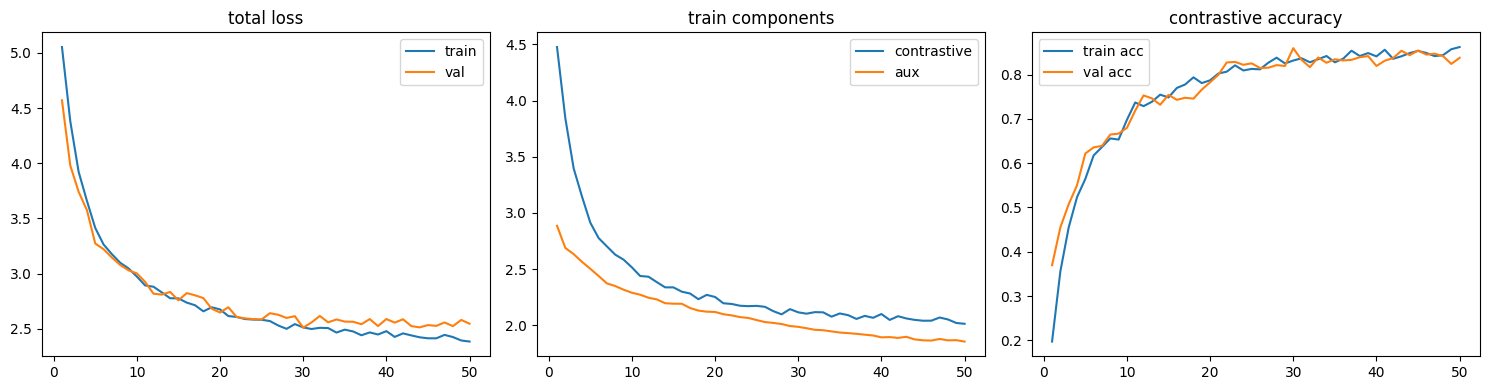

In [3]:
import pandas as pd
h = pd.read_csv(EXPORT/'loss_history.csv')
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(h['epoch'], h['train_loss'], label='train'); ax[0].plot(h['epoch'], h['val_loss'], label='val')
ax[0].set_title('total loss'); ax[0].legend()
ax[1].plot(h['epoch'], h['train_con'], label='contrastive'); ax[1].plot(h['epoch'], h['train_aux'], label='aux')
ax[1].set_title('train components'); ax[1].legend()
ax[2].plot(h['epoch'], h['train_acc'], label='train acc'); ax[2].plot(h['epoch'], h['val_acc'], label='val acc')
ax[2].set_title('contrastive accuracy'); ax[2].legend()
plt.tight_layout(); plt.show()

## Embedding analysis (norm, PCA colored by behavior)

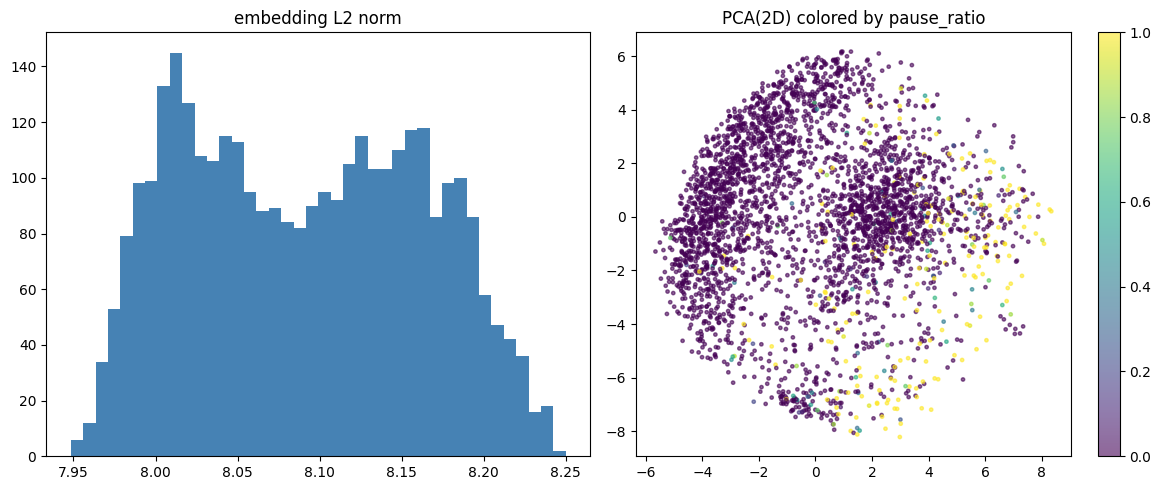

In [4]:
from scripts.embedders import embedder_common as ec
X, F, sessions, _ = ec.build_keyboard_windows(ROOT/'data')
import importlib.util
spec = importlib.util.spec_from_file_location('kb_out', EXPORT/'output.py')
kbo = importlib.util.module_from_spec(spec); spec.loader.exec_module(kbo)
sess = kbo.load_model(export_dir=EXPORT, device='cpu')
E = np.stack([kbo.get_output(sess, X[i])['embedding'] for i in range(len(X))])
norms = np.linalg.norm(E, axis=1)
Ec = E - E.mean(0); U,S,Vt = np.linalg.svd(Ec, full_matrices=False); pcs = Ec@Vt[:2].T
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(norms, bins=40, color='steelblue'); ax[0].set_title('embedding L2 norm')
feat = F[:, ec.KB_FEATURES.index('pause_ratio')]
sc = ax[1].scatter(pcs[:,0], pcs[:,1], c=feat, cmap='viridis', s=6, alpha=0.6)
ax[1].set_title('PCA(2D) colored by pause_ratio'); plt.colorbar(sc, ax=ax[1])
plt.tight_layout(); plt.show()

## Behavioral correlation (per feature)

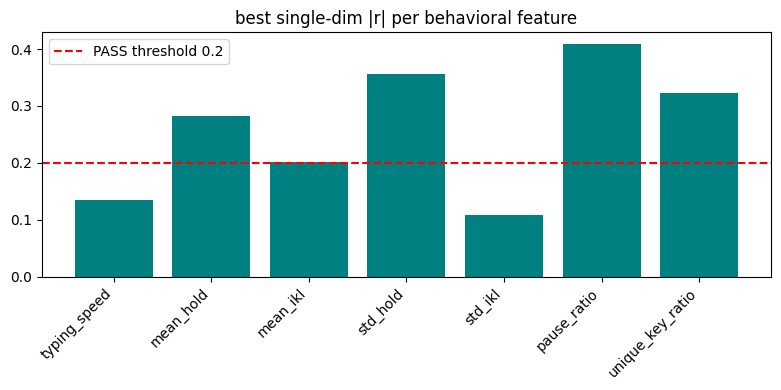

best |r| = 0.409 on pause_ratio


In [5]:
d = json.load(open(VAL/'keyboard_validation.json'))
pf = d['behavioral_correlation']['per_feature']
plt.figure(figsize=(8,4)); plt.bar(pf.keys(), pf.values(), color='teal')
plt.axhline(0.2, color='r', ls='--', label='PASS threshold 0.2'); plt.legend()
plt.title('best single-dim |r| per behavioral feature'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print('best |r| =', round(d['behavioral_correlation']['best_abs_r'],3), 'on', d['behavioral_correlation']['best_feature'])

## Validation gate

In [6]:
d = json.load(open(VAL/'keyboard_validation.json'))
print('STATUS :', d['status'])
print('allowed_for_tucker:', d['allowed_for_tucker'])
print('reasons:', d['reasons'])
h=d['health']; print('\nvariance_mean:', h['variance_mean'], '| cold_ratio:', h['cold_start_ratio'],
      '| dup:', h['duplicate_ratio'], '| n_valid:', h['n_valid'])

STATUS : PASS
allowed_for_tucker: True
reasons: []

variance_mean: 1.0229231119155884 | cold_ratio: 0.0 | dup: 0.0 | n_valid: 3303


## Export
The best checkpoint is already written to `pre_embedders/keyboard/exports/keyboard_encoder_final/encoder.pt`
by the training script. Re-run validation with:
```
python scripts/embedders/validate_embedders_final.py --only keyboard --device cpu
```